


---

## 五、K-Means聚类完整流程
1.  **数据探索**：检查变量分布，处理偏态数据（如百分位秩转换）。
2.  **模型构建**：初始化K-Means，尝试不同 \(k\) 值。
3.  **模型评估**：通过离差平方和与轮廓系数，确定最佳 \(k\)。
4.  **结果解读**：结合业务知识，为每个簇命名并制定营销策略。

---

### 总结：K-Means vs 层次聚类
| 特性 | K-Means | 层次聚类 |
| :--- | :--- | :--- |
| **聚类数** | 需预先指定 \(k\) | 可通过层次树自动确定 |
| **计算效率** | 快，适合大数据 | 慢，适合小样本 |
| **可解释性** | 一般 | 强，可直观看到聚类过程 |
| **适用场景** | 客户分群、异常检测等大规模场景 | 学术研究、小样本探索性分析 |

---


## 一、K-Means聚类原理
### 1. 核心思想
- **预先指定聚类数 $k$**：将 $n$ 个数据点划分到 $k$ 个类别中，使每个点都属于离它最近的聚类中心。
- **迭代优化**：通过不断更新聚类中心，直到中心不再变化（或变化小于阈值），完成最终分类。

### 2. 算法步骤（以 $k=2$ 为例）
1.  **随机设定 $k$ 个群组中心**。
2.  **计算各点到各中心的距离**，并将其归至最近的群组。
3.  **重新计算各群组中心**（取组内均值）。
4.  **再次计算各点到各中心的距离**，重新归类。
5.  **重复步骤3-4**，直到中心不再变化，完成分类。

### 3. 算法特点
- **时间复杂度**：$O(nkid)$ 或 $O(n)$，远低于层次聚类的$(O(n^3)$，适合**大数据量**场景。
- **优点**：计算速度快，原理易理解。
- **缺点**：
  1.  $k$ 值需人为指定，依赖业务经验。
  2.  易陷入**局部最优**，初始中心不同可能导致结果不同。
  3.  对**异常值敏感**。
  4.  不适合发现**非凸形状**的簇。


## 二、Python实现K-Means聚类

### 1.数据准备

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rc('font',**{'family':'Microsoft YaHei,SimHei'})
# 设置中文字体支持
plt.rcParams['axes.unicode_minus'] = False
# 解决保存图像是负号，‘-’显示为方块的问题
df = pd.read_csv('data_clean.csv')
df.head()


,ATM_POS,TBM,CSC
0,-0.852354,-0.294938,0.143935
1,-0.333078,-0.244334,0.939343
2,0.918067,0.593787,2.349496
3,-0.741847,-0.210507,-0.521592
4,-0.499703,-0.492714,-0.367629


- **变量含义**：
  - `CSC`：选择柜台服务的客户
  - `ATM_POS`：使用ATM和POS服务的客户
  - `TBM`：选择有偿服务的客户

### 2.基础聚类

In [2]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
result = kmeans.fit(df)
result

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [4]:
# 对分类结果进行解读
model_data_1 = df.join(pd.DataFrame(result.labels_))
model_data_1 = model_data_1.rename(columns={0:'clustor'})
model_data_1.sample(10)

,ATM_POS,TBM,CSC,clustor
42751,0.415057,-0.031330,-0.337254,0
3147,-0.035284,-0.338450,-0.505265,0
34734,-0.908314,0.062937,4.891263,1
46370,-0.814774,-0.482282,-0.433770,0
11601,-0.853765,-0.514305,-0.502691,0
58673,1.245518,-0.574863,-0.128827,1
56898,0.704572,-0.473841,-0.064623,0
71669,-0.882966,0.226220,-0.501698,0
95498,-0.526480,0.935564,-0.279494,0
19421,-0.885961,-0.509962,-0.507490,0


### 3. 数据转换（解决偏态分布问题）
原始数据偏度大，导致聚类结果极不均衡，需进行数据转换：

#### 常用转换方法
| 方法 | 原理                      | 优点 | 缺点 |
| :--- |:------------------------| :--- | :--- |
| **自然对数** | $y = \log_e x$，将右偏数据线性化 | 简单直观 | 无法处理≤0的数据 |
| **百分位秩** | 按大小排序，用百分位数代替原始值        | 消除量纲影响，可跨数据比较 | 大数据集下计算耗时 |
| **Tukey正态分布打分** | 幂次变换，使数据更对称             | 降低极端值影响 | 实现相对复杂 |

In [5]:
# 定义函数，用来实现K-Means建模流程，并给出可视化图
def kmeans_model_pie(data,k):
    '''传入数据和聚类个数，实现建模并绘制模型分类分布饼图'''
    kmeans = KMeans(n_clusters=k)
    result = kmeans.fit(data)
    model_data_1 = data.join(pd.DataFrame(result.labels_))
    model_data_1 = model_data_1.rename(columns={0:'clustor'})

    import matplotlib
    get_ipython().magic('matplotlib inline')
    model_data_1.clustor.value_counts().plot(kind='pie',shadow = True,autopct='%.2f%%')#两位小数

C:\Users\24677\AppData\Local\Temp\ipykernel_48372\3069814856.py:10: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  get_ipython().magic('matplotlib inline')


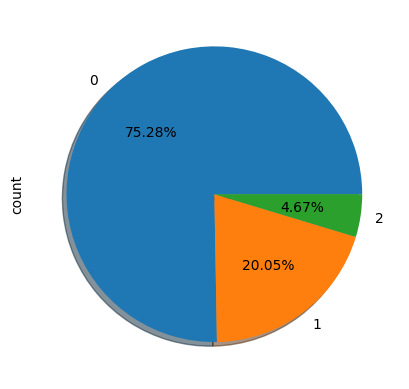

In [6]:
# 标准化数据后再次建模，使用中心标准化
df_normalized = df.apply(lambda x: (x - x.mean()) / x.std())
kmeans_model_pie(data = df_normalized,k = 3)

In [7]:
# 自变量的偏度检查
var = ['ATM_POS','TBM','CSC']
skew_var = {}
for i in var:
    skew_var[i] = df_normalized[i].skew()# skew求该变量的偏度
    skew = pd.Series(skew_var).sort_values(ascending=False)
skew

TBM        51.881233
CSC         6.093417
ATM_POS     2.097633
dtype: float64

百分位秩转换法的实现：

In [8]:
from sklearn import preprocessing
quantile_transformer = preprocessing.QuantileTransformer(
    output_distribution='normal',
    random_state = 0
)#正态转换
df_trans = quantile_transformer.fit_transform(df)
df_trans = pd.DataFrame(df_trans)
df_trans = df_trans.rename(columns={0:'ATM_POS',1:'TBM',2:'CSC'})
df_trans.head()

,ATM_POS,TBM,CSC
0,-0.500074,-0.263286,0.771350
1,0.095454,-0.142501,1.309555
2,0.933541,1.175246,1.836506
3,-0.330865,-0.079463,-1.776468
4,-0.071296,-0.897128,-0.067301


C:\Users\24677\AppData\Local\Temp\ipykernel_48372\3069814856.py:10: DeprecationWarning: `magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).
  get_ipython().magic('matplotlib inline')


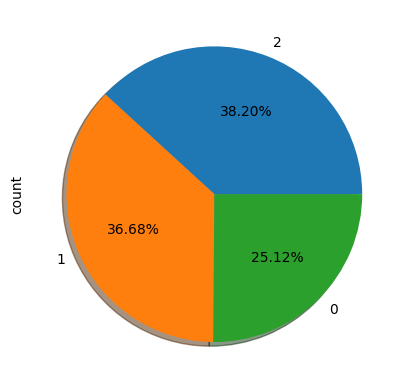

In [9]:
kmeans_model_pie(data = df_trans,k = 3)


## 三、模型评估
### 1. 核心评估指标
- **组内离差平方和（inertia）**：所有样本到其所属簇中心的距离平方和，**值越小，组内越紧凑**。
- **轮廓系数（Silhouette Coefficient）**：取值 $[-1,1]$，越接近1表示**组内紧凑、组间分离**，聚类效果越好。


### 2.寻找最佳k值

In [10]:
from sklearn.metrics import silhouette_score

data = df_trans.sample(1500)

# 这段代码的运行需要耐心等待一段时间
Ks = range(2,10)# 聚类个数k，2~10个
rssds = [];silhs = []#用来储存租给离差平方和和轮廓系数
for k in Ks:
    model = KMeans(n_clusters=k,n_init=15)
    # n_init 表示初始质心
    model.fit(data)
    rssds.append(model.inertia_)
    silhs.append(silhouette_score(data,model.labels_))

Text(0.5, 1.0, '离差平方和')

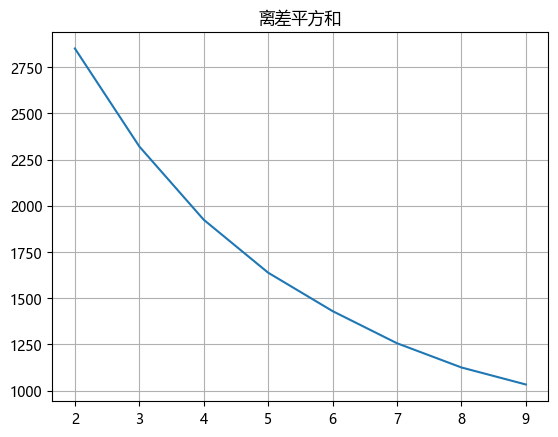

In [19]:
import matplotlib.pyplot as plt

plt.plot(Ks, rssds, label='K-Means')
plt.grid(True)
plt.title('离差平方和')


Text(0.5, 1.0, '轮廓系数')

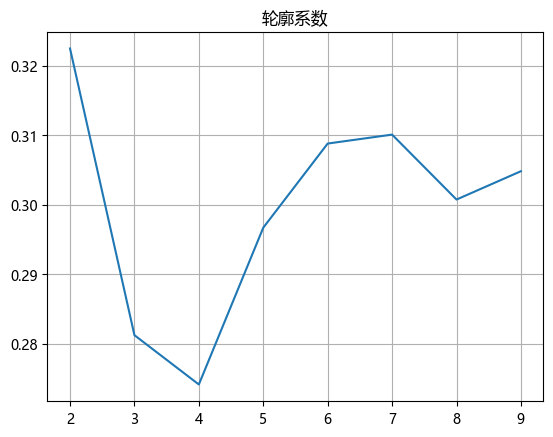

In [17]:
plt.plot(Ks, silhs, label='Silhouette Score')
plt.grid(True)
plt.title('轮廓系数')


- **选择逻辑**：
  1.  离差平方和：选择**下降最显著**的拐点（“肘部”）。
  2.  轮廓系数：选择**值最大**的 \(k\)。
  3.  综合判断：本章案例中，\(k=3\) 为最佳选择。


## 四、结果分析与业务解读
### 1. 客户分群结果
基于 $k=3$ 的聚类结果，汇总各簇指标均值，得到三类客户：

| 类别 | 表现（渠道使用偏好） | 业务猜测 | 客户名称 |
| :--- | :--- | :--- | :--- |
| **0** | 传统渠道（柜台、ATM/POS）使用频率低，新兴渠道（TBM）使用频率高 | 资金不算充裕，但有交易需求，乐于尝试新渠道 | **年轻潜力客户** |
| **1** | 新兴渠道使用最少，传统渠道使用频率较低 | 资金不算充裕的中老年客户 | **中价值中老年群体** |
| **2** | 传统渠道使用频率最高，新兴渠道使用最少 | 资金充裕的中老年客户，业务种类多，对新渠道不熟悉 | **高价值中老年客户** |

### 2. 业务应用
- **年轻潜力客户**：可重点推广新兴渠道优惠，培养用户习惯。
- **高价值中老年客户**：可针对性推广线下理财、保险等产品，或向其子女推荐线上服务。
- **中价值中老年群体**：可通过传统渠道进行客户关怀，提升留存。

---


## 五、K-Means聚类完整流程
1.  **数据探索**：检查变量分布，处理偏态数据（如百分位秩转换）。
2.  **模型构建**：初始化K-Means，尝试不同 $k$ 值。
3.  **模型评估**：通过离差平方和与轮廓系数，确定最佳 $k$。
4.  **结果解读**：结合业务知识，为每个簇命名并制定营销策略。

---



### 总结：K-Means vs 层次聚类
| 特性 | K-Means         | 层次聚类 |
| :--- |:----------------| :--- |
| **聚类数** | 需预先指定 $k$       | 可通过层次树自动确定 |
| **计算效率** | 快，适合大数据         | 慢，适合小样本 |
| **可解释性** | 一般              | 强，可直观看到聚类过程 |
| **适用场景** | 客户分群、异常检测等大规模场景 | 学术研究、小样本探索性分析 |